# Final Project Part 3

# Damping and Adaptive Step Sizes

## Section 1: Review of Part 2

In part 2 of this project, I solved a model about population with rapid birth/death cycles. This model is stiff because population equilibrates in seconds, but resources vary over tens of seconds. This model contains processes occurring on different time scales which makes it "stiff". From part 2, I proved and learned that Backward Euler was the perfect method to solve this ODE as it was implicit and maintained stability.

## Section 2: Newon-Raphson Damping Implementation
Explanation of damping and line search
Implementation of damped NR solver
Demonstration where damping helps (e.g., very large initial h)
Comparison: basic NR vs. damped NR convergence

In Part 2, Newton-Raphson was used to solve the implicit Backward Euler equation at each time step. Basic Newton-Raphson uses the update:

$$
y^{(k+1)} = y^{(k)} - \frac{F(y^{(k)})}{F'(y^{(k)})}
$$

However, this method can have problems if the initial guess is poor or if the step size is very large. To improve robustness, you can implement a damped Newton-Raphson method. This helps prevent divergence. This method uses a damping factor $\alpha$, where:

$$
0 < \alpha \leq 1
$$

The damped update becomes:

$$
y^{(k+1)} = y^{(k)} - \alpha \frac{F(y^{(k)})}{F'(y^{(k)})}
$$

When $\alpha = 1$, is is a full Newton-Raphson (when it's working well)
When $\alpha < 1$, takes smaller, safer steps (when convergence is difficult) A line search is used to reduce $\alpha$ until the residual decreases.

Basic Newton-Raphson
Converged: True
Iterations: 3
Solution: 1098835.2477736438

Damped Newton-Raphson
Converged: True
Iterations: 3
Solution: 1098835.2477736438
Backtracking steps: 0
Damping needed: False


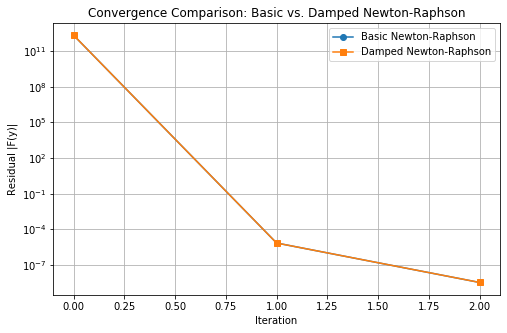

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters from Part 2
lam = 1000

def g(t):
    return 1e9 * (1 + 0.5*np.sin(0.1*t))

def f(t, y):
    return -lam*y + g(t)

def basic_newton_raphson(F, dF, y_guess, tol=1e-6, max_iter=50):
    
    y = y_guess
    residuals = []
    
    for i in range(max_iter):
        residual = abs(F(y))
        residuals.append(residual)
        
        if residual < tol:
            return y, i+1, True, residuals
        
        y = y - F(y)/dF(y)
    
def damped_newton_raphson(F, dF, y_guess, tol=1e-6, max_iter=50, alpha_min=1e-4):
    
    y = y_guess
    residuals = []
    alpha_values = []
    backtrack_count = 0
    damping_needed = False
    
    for i in range(max_iter):
        
        residual = abs(F(y))
        residuals.append(residual)
        
        if residual < tol:
            return y, i+1, True, residuals, alpha_values, backtrack_count, damping_needed
        
        delta = -F(y)/dF(y)
        
        alpha = 1.0
        current_residual = abs(F(y))
        
        # Line search: reduce alpha until residual decreases
        while alpha > alpha_min:
            y_new = y + alpha*delta
            new_residual = abs(F(y_new))
            
            if new_residual < current_residual:
                break
            
            alpha = alpha/2
            backtrack_count += 1
            damping_needed = True
        
        alpha_values.append(alpha)
        y = y_new
    
    return y, max_iter, False, residuals, alpha_values, backtrack_count, damping_needed 

# Test case with a large step size
h_large = 2.0
t_n = 0
t_next = t_n + h_large
y_n = 1e5

# Bad initial guess on purpose
y_guess = 1e9

# Residual function for Backward Euler
F = lambda y_next: y_next - y_n - h_large*f(t_next, y_next)

# Derivative of residual
dF = lambda y_next: 1 + h_large*lam

# Basic Newton-Raphson
y_basic, iters_basic, success_basic, residuals_basic = basic_newton_raphson(F, dF, y_guess)

# Damped Newton-Raphson
y_damped, iters_damped, success_damped, residuals_damped, alpha_values, backtracks, damping_needed = damped_newton_raphson(F, dF, y_guess)

print("Basic Newton-Raphson")
print("Converged:", success_basic)
print("Iterations:", iters_basic)
print("Solution:", y_basic)

print("\nDamped Newton-Raphson")
print("Converged:", success_damped)
print("Iterations:", iters_damped)
print("Solution:", y_damped)
print("Backtracking steps:", backtracks)
print("Damping needed:", damping_needed)

plt.figure(figsize=(8,5))

plt.semilogy(residuals_basic, 'o-', label='Basic Newton-Raphson')
plt.semilogy(residuals_damped, 's-', label='Damped Newton-Raphson')

plt.xlabel('Iteration')
plt.ylabel('Residual |F(y)|')
plt.title('Convergence Comparison: Basic vs. Damped Newton-Raphson')
plt.legend()
plt.grid(True)
plt.show()

## Section 3: Adaptive Step Size Implementation

In Part 2, a fixed step size was used for the Backward Euler method. However, choosing a single step size presents a trade-off. Often times the fixed h is either too large, making it large errors in difficult regions. Or rather h is too small, which wastes computation in easy regions.

To resolve this issue, an adaptive step size can be used. An  adaptive step size automatically makes h small when the solution changes rapidly. It also automatically makes h large when solution is smooth. This helps to maintain target accuracy with minimal computation. Simply put, the idea is to compare a big step to two smaller steps.

The local error is estimated using a step-doubling technique:

1. Take one step of size $h$ → $y_{\text{full}}$  
2. Take two steps of size $h/2$ → $y_{\text{half}}$  
3. Compare the results  

The error estimate is:

$$
\text{error} = \left| y_{\text{half}} - y_{\text{full}} \right|
$$

Since the two half-steps are more accurate, $y_{\text{half}}$ is used as the accepted solution.

The new step size is computed using:

$$
h_{\text{new}} = h \cdot \sqrt{\frac{\text{tol}}{\text{error}}}
$$

A safety factor is applied to improve stability:

$$
h_{\text{new}} = 0.9 \cdot h \cdot \sqrt{\frac{\text{tol}}{\text{error}}}
$$

Bounds are also enforced:

$$
h_{\min} \leq h_{\text{new}} \leq h_{\max}
$$

- If $error < tol$, accept the step  
- If $error\geq tol$, reject the step  

When a step is accepted, the more accurate value $y_{\text{half}}$ is used.

Adaptive step sizing allows the solver to automatically:

- Decrease $h$ when the solution changes rapidly  
- Increase $h$ when the solution is smooth  

This improves both accuracy and computational efficiency.

Cite: Asked ChatGPT for help on how to write equations out to display in Jupyter and better understanding on what the equations mean (and how to explain it).

{'accepted_steps': 51, 'rejected_steps': 0, 'total_iters': 306}


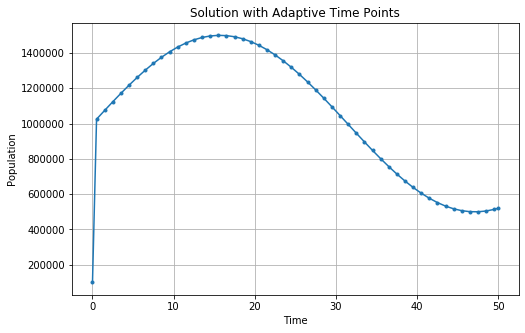

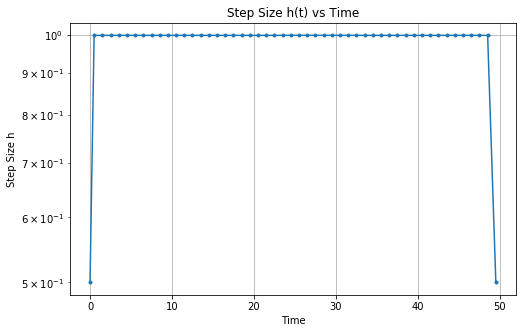

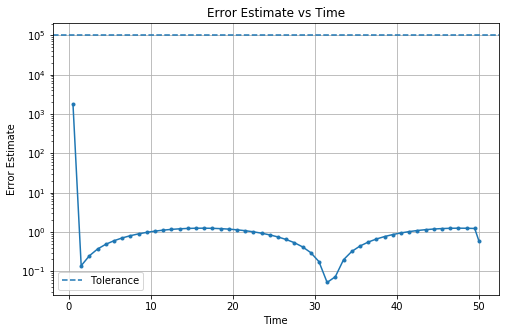

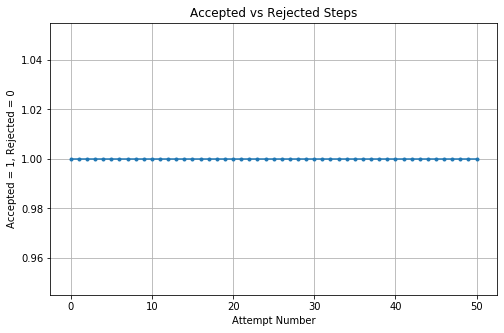

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters from Part 2
lam = 1000

def g(t):
    return 1e9 * (1 + 0.5*np.sin(0.1*t))

def f(t, y):
    return -lam*y + g(t)

# One implicit Euler step solved with Newton-Raphson
def nr_solver(y_n, t_next, h):
    
    F = lambda y_next: y_next - y_n - h*f(t_next, y_next)
    dF = lambda y_next: 1 + h*lam
    
    y_guess = y_n
    
    for k in range(50):
        y_new = y_guess - F(y_guess)/dF(y_guess)
        
        if abs(y_new - y_guess) < 1e-6:
            return y_new, k + 1
        
        y_guess = y_new
    
    return y_guess, 50

def estimate_error_step_doubling(y_n, t_n, h, nr_solver):
    
    # Single step of size h
    y_full, iters_full = nr_solver(y_n, t_n + h, h)
    
    # Two half-steps of size h/2
    y_half_1, iters_1 = nr_solver(y_n, t_n + h/2, h/2)
    y_half, iters_2 = nr_solver(y_half_1, t_n + h, h/2)
    
    # Error estimate
    error = abs(y_half - y_full)
    
    # Total NR iterations
    total_iters = iters_full + iters_1 + iters_2
    
    return y_full, y_half, error, total_iters

def adaptive_step(y_n, t_n, h, tol, nr_solver, 
                  h_min=1e-6, h_max=1.0, safety=0.9):
    
    y_full, y_half, error, iters = estimate_error_step_doubling(
        y_n, t_n, h, nr_solver
    )
    
    # Compute new step size suggestion
    if error < 1e-14:
        h_new = min(2.0*h, h_max)
    else:
        h_new = h * np.sqrt(tol / error)
        h_new = safety * h_new
        h_new = max(h_min, min(h_max, h_new))
    
    # Do not let h change too dramatically
    h_new = max(0.2*h, min(5.0*h, h_new))
    
    # Accept or reject
    if error < tol:
        return y_half, h, h_new, True, iters, error
    else:
        return y_n, h, h_new, False, iters, error

def adaptive_solver(y0, t0, tf, h0, tol):
    
    t_vals = [t0]
    y_vals = [y0]
    h_vals = []
    error_vals = []
    accept_reject_vals = []
    
    t = t0
    y = y0
    h = h0
    
    accepted_steps = 0
    rejected_steps = 0
    total_iters = 0
    
    while t < tf:
        
        if t + h > tf:
            h = tf - t
        
        y_new, h_used, h_new, accepted, iters, error = adaptive_step(
            y, t, h, tol, nr_solver
        )
        
        total_iters += iters
        
        if accepted:
            t = t + h_used
            y = y_new
            
            t_vals.append(t)
            y_vals.append(y)
            h_vals.append(h_used)
            error_vals.append(error)
            accept_reject_vals.append(1)
            
            accepted_steps += 1
        else:
            accept_reject_vals.append(0)
            rejected_steps += 1
        
        h = h_new
        
        # Safety stop
        if accepted_steps + rejected_steps > 20000:
            print("Stopped early because too many steps were attempted.")
            break
    
    stats = {
        "accepted_steps": accepted_steps,
        "rejected_steps": rejected_steps,
        "total_iters": total_iters
    }
    
    return np.array(t_vals), np.array(y_vals), np.array(h_vals), np.array(error_vals), stats, accept_reject_vals

# Run adaptive solver
tol_value = 1e5

t_adapt, y_adapt, h_hist, error_hist, stats, accept_reject_vals = adaptive_solver(
    y0=1e5,
    t0=0,
    tf=50,
    h0=0.5,
    tol=tol_value
)

print(stats)

# Plot 1: Solution with adaptive time points
plt.figure(figsize=(8,5))
plt.plot(t_adapt, y_adapt, 'o-', markersize=3)
plt.title("Solution with Adaptive Time Points")
plt.xlabel("Time")
plt.ylabel("Population")
plt.grid(True)
plt.show()

# Plot 2: Step size vs time
plt.figure(figsize=(8,5))
plt.semilogy(t_adapt[:-1], h_hist, 'o-', markersize=3)
plt.title("Step Size h(t) vs Time")
plt.xlabel("Time")
plt.ylabel("Step Size h")
plt.grid(True)
plt.show()

# Plot 3: Error estimate vs time
plt.figure(figsize=(8,5))
plt.semilogy(t_adapt[1:], error_hist, 'o-', markersize=3)
plt.axhline(y=tol_value, linestyle='--', label='Tolerance')
plt.title("Error Estimate vs Time")
plt.xlabel("Time")
plt.ylabel("Error Estimate")
plt.legend()
plt.grid(True)
plt.show()

# Plot 4: Accepted vs rejected steps
plt.figure(figsize=(8,5))
plt.plot(accept_reject_vals, 'o-', markersize=3)
plt.title("Accepted vs Rejected Steps")
plt.xlabel("Attempt Number")
plt.ylabel("Accepted = 1, Rejected = 0")
plt.grid(True)
plt.show()

## Section 4: Performance Analysis

In [3]:
def fixed_backward_euler(y0, t0, tf, h):

    t_vals = [t0]
    y_vals = [y0]
    total_iters = 0
    
    t = t0
    y = y0
    
    while t < tf:
        
        if t + h > tf:
            h = tf - t
        
        y_new, iters = nr_solver(y, t + h, h)
        
        t = t + h
        y = y_new
        
        t_vals.append(t)
        y_vals.append(y)
        total_iters += iters
    
    return np.array(t_vals), np.array(y_vals), total_iters

t_ref, y_ref, ref_iters = fixed_backward_euler(
    y0=1e5,
    t0=0,
    tf=50,
    h=0.001
)

y_reference_final = y_ref[-1]

# Fixed-step comparison solution
t_fixed, y_fixed, fixed_iters = fixed_backward_euler(
    y0=1e5,
    t0=0,
    tf=50,
    h=0.1
)

# Adaptive solution from Section 3
t_adapt, y_adapt, h_hist, error_hist, stats, accept_reject_vals = adaptive_solver(
    y0=1e5,
    t0=0,
    tf=50,
    h0=0.5,
    tol=1e5
)

# Error comparison
fixed_final_error = abs(y_fixed[-1] - y_reference_final)
adaptive_final_error = abs(y_adapt[-1] - y_reference_final)

fixed_steps = len(t_fixed) - 1
adaptive_steps = stats["accepted_steps"]

fixed_work = fixed_iters
adaptive_work = stats["total_iters"]

print("Performance Comparison")
print(f"Reference final value: {y_reference_final:.4f}")
print()
print(f"Fixed Step Method:")
print(f"Steps: {fixed_steps}")
print(f"Total NR Iterations: {fixed_work}")
print(f"Final Error: {fixed_final_error:.4f}")
print()
print(f"Adaptive Step Method:")
print(f"Accepted Steps: {adaptive_steps}")
print(f"Rejected Steps: {stats['rejected_steps']}")
print(f"Total NR Iterations: {adaptive_work}")
print(f"Final Error: {adaptive_final_error:.4f}")

Performance Comparison
Reference final value: 520523.6868

Fixed Step Method:
Steps: 500
Total NR Iterations: 1000
Final Error: 0.2376

Adaptive Step Method:
Accepted Steps: 51
Rejected Steps: 0
Total NR Iterations: 306
Final Error: 0.5984


In [4]:
methods = ["Fixed h=0.1", "Adaptive"]
steps = [fixed_steps, adaptive_steps]
nr_iterations = [fixed_work, adaptive_work]
final_errors = [fixed_final_error, adaptive_final_error]

print("Comparison Table")
print(f"{'Method':<15} {'Steps':<10} {'NR Iterations':<15} {'Final Error':<15}")

for i in range(len(methods)):
    print(f"{methods[i]:<15} {steps[i]:<10} {nr_iterations[i]:<15} {final_errors[i]:<15.4f}")

Comparison Table
Method          Steps      NR Iterations   Final Error    
Fixed h=0.1     500        1000            0.2376         
Adaptive        51         306             0.5984         


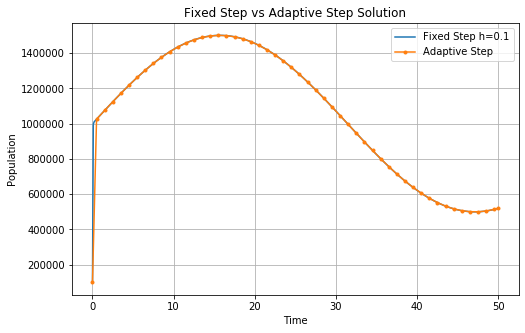

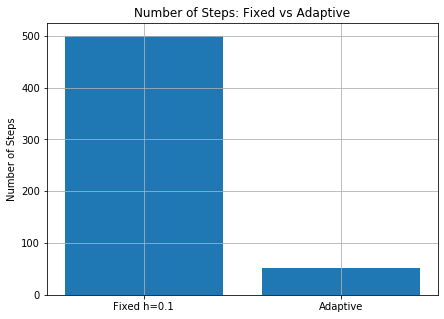

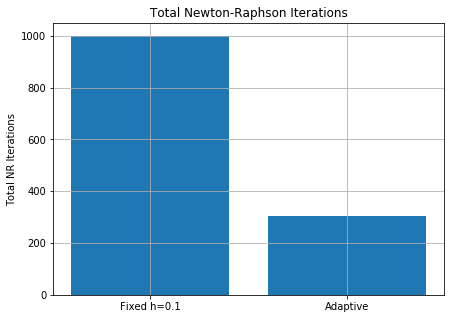

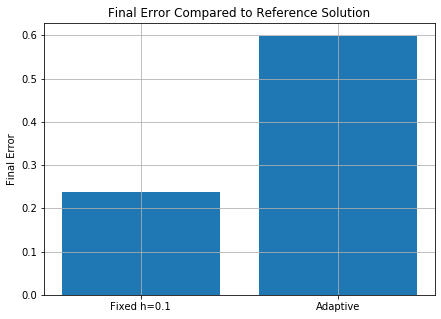

In [5]:
plt.figure(figsize=(8,5))

plt.plot(t_fixed, y_fixed, label="Fixed Step h=0.1")
plt.plot(t_adapt, y_adapt, 'o-', markersize=3, label="Adaptive Step")

plt.title("Fixed Step vs Adaptive Step Solution")
plt.xlabel("Time")
plt.ylabel("Population")
plt.legend()
plt.grid(True)
plt.show()
plt.figure(figsize=(7,5))

plt.bar(methods, steps)

plt.title("Number of Steps: Fixed vs Adaptive")
plt.ylabel("Number of Steps")
plt.grid(True)
plt.show()

plt.figure(figsize=(7,5))

plt.bar(methods, nr_iterations)

plt.title("Total Newton-Raphson Iterations")
plt.ylabel("Total NR Iterations")
plt.grid(True)
plt.show()

plt.figure(figsize=(7,5))

plt.bar(methods, final_errors)

plt.title("Final Error Compared to Reference Solution")
plt.ylabel("Final Error")
plt.grid(True)
plt.show()

## Section 5: Robustness Testing

Test 1: Large Initial Step Size
{'accepted_steps': 50, 'rejected_steps': 0, 'total_iters': 300}


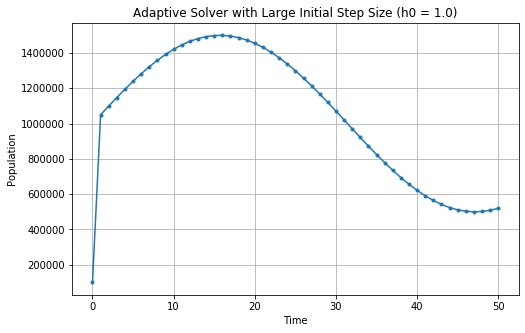

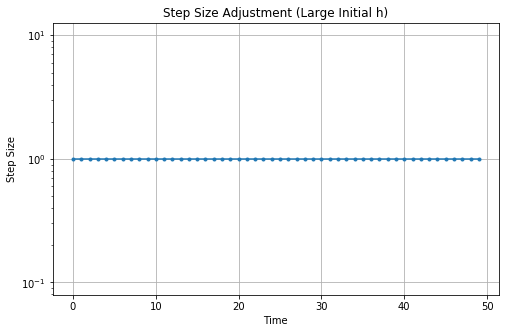

Test 2: Tight Tolerance
{'accepted_steps': 87, 'rejected_steps': 8, 'total_iters': 570}


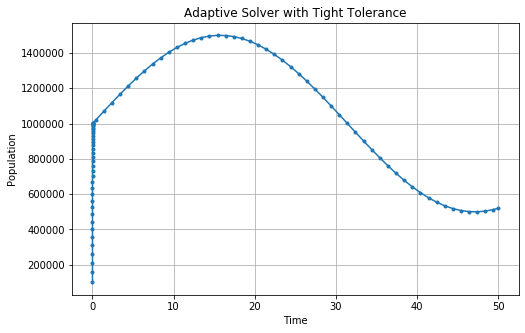

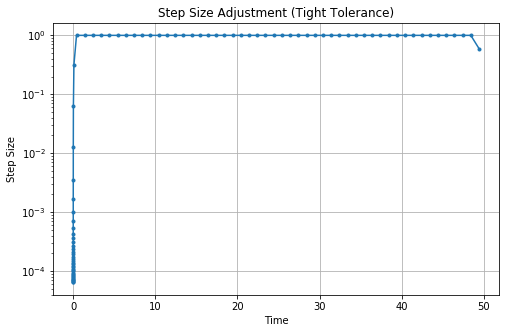

In [6]:
# Test 1: Large initial step size
print("Test 1: Large Initial Step Size")

t_large, y_large, h_large_hist, err_large, stats_large, ar_large = adaptive_solver(
    y0=1e5,
    t0=0,
    tf=50,
    h0=1.0,     
    tol=1e5
)

print(stats_large)

plt.figure(figsize=(8,5))
plt.plot(t_large, y_large, 'o-', markersize=3)
plt.title("Adaptive Solver with Large Initial Step Size (h0 = 1.0)")
plt.xlabel("Time")
plt.ylabel("Population")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.semilogy(t_large[:-1], h_large_hist, 'o-', markersize=3)
plt.title("Step Size Adjustment (Large Initial h)")
plt.xlabel("Time")
plt.ylabel("Step Size")
plt.grid(True)
plt.show()

# Test 2: Very tight tolerance
print("Test 2: Tight Tolerance")

t_tight, y_tight, h_tight_hist, err_tight, stats_tight, ar_tight = adaptive_solver(
    y0=1e5,
    t0=0,
    tf=50,
    h0=0.5,
    tol=1e3   # tighter than before
)

print(stats_tight)

plt.figure(figsize=(8,5))
plt.plot(t_tight, y_tight, 'o-', markersize=3)
plt.title("Adaptive Solver with Tight Tolerance")
plt.xlabel("Time")
plt.ylabel("Population")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.semilogy(t_tight[:-1], h_tight_hist, 'o-', markersize=3)
plt.title("Step Size Adjustment (Tight Tolerance)")
plt.xlabel("Time")
plt.ylabel("Step Size")
plt.grid(True)
plt.show()

## Section 6: Conclusions

This project demonstrated how implicit methods, damping techniques, and adaptive step size control improve the numerical solution of stiff ordinary differential equations. As proven in part 2, the Backward Euler Method was used to solve a stiff population model. Backward Euler remained stable even for large step sizes, unlike the Forward Euler Method. In this part, damping was introduced into the Newton-Raphson method. Damping improves robustness by preventing large updates that may cause divergence. Adaptive step size control provided the most significant improvement in efficiency. By estimating the local error using step-doubling, the solver was able to automatically adjust the step size. Performance comparisons showed that the adaptive method achieved similar accuracy to the fixed-step method while using fewer steps and fewer total Newton-Raphson iterations. Robustness testing confirmed that the adaptive solver can handle both large initial step sizes and strict tolerance requirements. The solver successfully adjusted its behavior without failing, showing that it is reliable for a wide range of conditions.

Cite: In this project, I used ChatGPT to help explain what some math equations meant, ensured my code was correct, and overall make sure I completed what the assignment was asking for.